# 05. Gene expression programs and the genotype-phenotype map (Fig. 4B-D)

Paper (STAR Methods p. e12): each gene is represented by its z-normalized expression across the strong
perturbations (targets masked), embedded in 20 dimensions with pyMDE (`n_neighbors=7`, `repulsive_fraction=5`),
and clustered with HDBSCAN (`metric='euclidean', min_cluster_size=10, min_samples=10,
cluster_selection_method='leaf'`), giving 38 programs. Fig. 4B averages expression within each
perturbation cluster (notebook 02) and each program.

In [1]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from sklearn.cluster import HDBSCAN
import gwps

gw = gwps.load("k562_gw")
clusters = pd.read_csv(gwps.RES / "k562_gw_strong_clusters.csv", index_col=0)
genes = pd.read_csv(gwps.RES / "k562_gw_selected_genes.csv")["gene_id"]
P = gwps.profiles(gw[clusters.index], genes)          # strong perturbations x genes
G = gwps.standardize_rows(P.values.T)                 # genes x perturbations, each gene z-normalized
emb = gwps.mde(G, dim=20)
programs = HDBSCAN(metric="euclidean", min_cluster_size=10, min_samples=10,
                   cluster_selection_method="leaf", copy=False).fit_predict(emb)
prog = pd.Series(programs, index=P.columns, name="program")
print(f"{programs.max() + 1} gene expression programs; {np.mean(programs == -1):.0%} of {len(prog)} genes unassigned")
prog.to_csv(gwps.RES / "k562_gw_gene_programs.csv")

39 gene expression programs; 51% of 2273 genes unassigned


## Report Fig. 9: gene expression programs in a two-dimensional MDE embedding

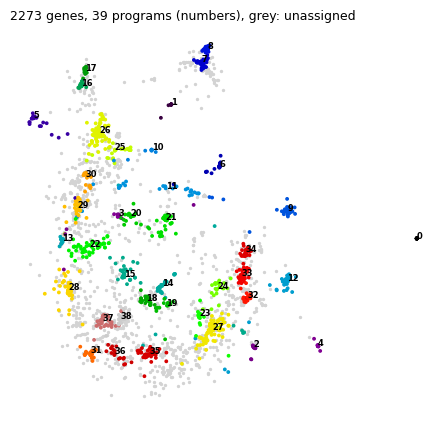

In [2]:
xy = gwps.mde(G, dim=2)
fig, ax = plt.subplots(figsize=(5.5, 5))
noise = programs == -1
ax.scatter(*xy[noise].T, s=2, c="lightgrey", rasterized=True, label="unassigned")
ax.scatter(*xy[~noise].T, s=3, c=programs[~noise], cmap="nipy_spectral", rasterized=True)
for k in range(programs.max() + 1):
    ax.text(*np.median(xy[programs == k], 0), str(k), fontsize=6, weight="bold")
ax.set_xticks([]); ax.set_yticks([]); [s.set_visible(False) for s in ax.spines.values()]
ax.set_title(f"{len(prog)} genes, {programs.max() + 1} programs (numbers), grey: unassigned", loc="left")
gwps.savefig(fig, "fig09_gene_programs_mde")

## Report Fig. 10: perturbation clusters x gene expression programs (cf. paper Fig. 4B)

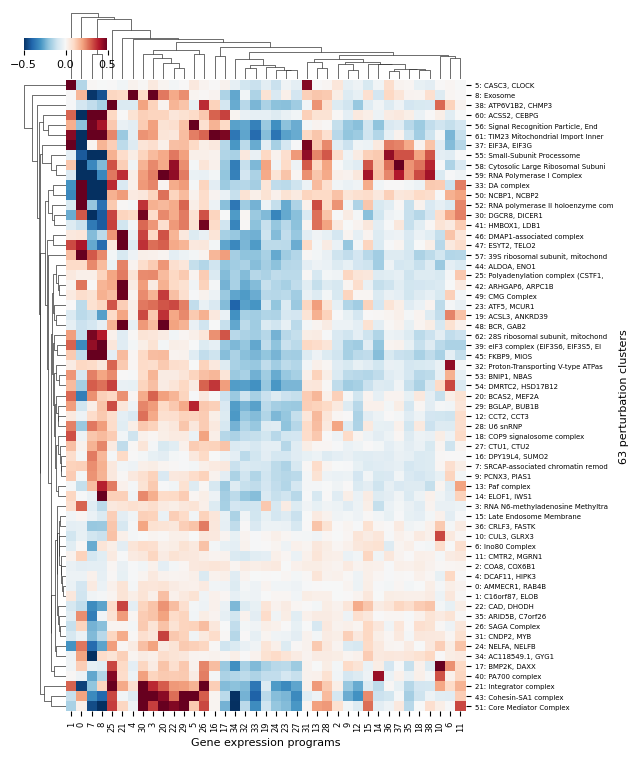

In [3]:
lab = clusters["cluster"].values
M = pd.DataFrame(P.values).groupby(lab).mean().drop(index=-1, errors="ignore")
M = M.T.groupby(programs).mean().drop(index=-1, errors="ignore").T     # perturbation clusters x programs
names = gwps.cluster_names(clusters["target"], lab, gwps.complex_library())
M.index = [f"{k}: {names[k]}" for k in M.index]
g = sns.clustermap(M, cmap=gwps.EXPR_CMAP, vmin=-0.5, vmax=0.5, method="average", figsize=(7, 7.5),
                   xticklabels=True, yticklabels=True, dendrogram_ratio=0.1, cbar_pos=(0.02, 0.93, 0.12, 0.015),
                   cbar_kws={"orientation": "horizontal"})
g.ax_heatmap.set_xlabel("Gene expression programs"); g.ax_heatmap.set_ylabel(f"{len(M)} perturbation clusters")
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=5); plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=6)
gwps.savefig(g.fig, "fig10_programs_heatmap")

## Report Fig. 11: ISR vs UPR and erythroid vs myeloid scores (cf. paper Fig. 4C, 4D)

In the paper the four signatures are gene expression programs (clusters 12, 2, 15 and 21). Here each signature is
the program that best matches a set of marker genes; the overlap with the gene lists hard-coded in the original
notebook is reported. Scores (paper): mean expression of the program genes for every perturbation detected in at
least 25 cells, then z-normalized across perturbations; the 15 most outlying perturbations are labelled.

In [4]:
markers = {"ISR": ["ATF4", "DDIT3", "TRIB3", "ASNS", "SESN2", "DDIT4"],
           "UPR": ["HSPA5", "HERPUD1", "PDIA4", "HYOU1", "SDF2L1", "MANF"],
           "Erythroid": ["HBG1", "HBG2", "HBZ", "KLF1", "GYPA", "TMOD1"],
           "Myeloid": ["SPI1", "LAPTM5", "CD33", "AIF1", "CD53", "LGALS1"]}
original = {   # gene lists from the original Section_7 notebook (source not documented)
    "ISR": ["SARS", "ZCCHC8", "GCAT", "XBP1", "TRIB3", "MDK", "RTN4", "IGFBP2", "CCND2", "ATF4", "SESN2", "MAP1B",
            "SLC31A1", "IDH1", "WARS", "HAX1", "DDIT4", "RNF41", "PRSS57", "COLGALT2", "CCPG1", "LINC00662"],
    "UPR": ["HSPA5", "HERPUD1", "TRAM1", "NUCB2", "MYDGF", "DNAJB11", "DNAJC3", "KDELR1", "SEC61B", "SSR3", "RPN2",
            "SERP1", "SSR1", "CANX", "SDF2L1", "TMED7", "KDELR2", "PDIA6", "MANF", "HYOU1", "PDIA4", "SSR2",
            "HSP90B1", "PPIB", "PDIA3", "CALR", "P4HB", "SND1", "DDOST"],
    "Erythroid": ["CHI3L2", "OAT", "BLVRB", "KLF1", "SLC2A1", "NENF", "NFE2", "UROD", "ASH2L", "APOC1", "HBZ", "TMOD1",
                  "HEMGN", "SLC39A8", "SORD", "MFGE8", "SLC25A37", "FEZ1", "ERMAP", "GFI1B", "STAT3", "FAM178B",
                  "TANGO2", "C2orf88", "HBG2", "ANXA6", "MYL4", "MPIG6B", "HBA1", "HBG1", "UCA1", "HBD", "PVT1",
                  "HMBS", "AC079466.1", "AC079801.1", "AP001531.1"],
    "Myeloid": ["WAS", "PIK3CB", "CYBA", "SPI1", "BAX", "LGALS1", "PYCARD", "TNNT1", "PLIN3", "CD33", "AIP", "ARPC3",
                "GNAI2", "VAMP8", "ELF1", "VASP", "RAC2", "ARHGEF6", "ARPC1B", "GMFG", "CAP1", "DOCK2", "PAPSS1",
                "SLC27A2", "EMP3", "SH3BGRL3", "EVA1B", "CD53", "PTPN7", "PPP1R18", "ABRACL", "MSN", "TAGLN2",
                "LAPTM5", "ARPC5", "S100A11", "TPM4", "GPRC5C", "CAVIN1", "FMNL1", "IFITM2", "SOCS1", "SMYD3",
                "STAC3", "SPN", "CFD", "TAFA2", "AIF1", "CLIC1"]}
assigned = prog[prog >= 0]
signatures, rows = {}, []
for name, mk in markers.items():
    hits = assigned[assigned.index.isin(mk)]
    k = hits.value_counts().idxmax()
    members = assigned.index[assigned == k]
    signatures[name] = members
    orig = set(original[name]) & set(prog.index)
    rows.append({"signature": name, "program": k, "genes": len(members), "marker genes in program": len(hits[hits == k]),
                 "original list genes in data": len(orig), "shared with original list": len(orig & set(members))})
pd.DataFrame(rows)

,signature,program,genes,marker genes in program,original list genes in data,shared with original list
0,ISR,16,14,2,17,7
1,UPR,5,33,6,28,26
2,Erythroid,21,40,4,29,27
3,Myeloid,26,66,4,42,39


10511 perturbations scored


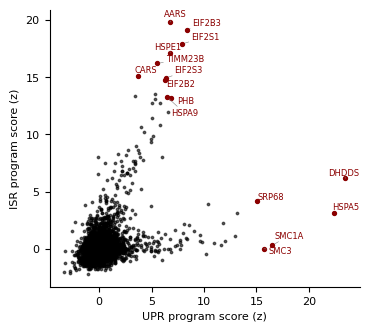

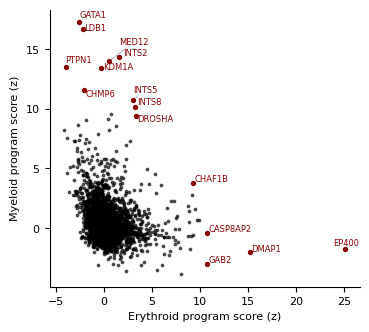

In [5]:
pert = gw.obs.index[~gw.obs["is_control"] & (gw.obs["num_cells_filtered"] >= 25)]
expr = gwps.profiles(gw[pert], genes)
scores = pd.DataFrame({n: expr.loc[:, expr.columns.isin(g)].mean(1) for n, g in signatures.items()})
scores = (scores - scores.mean()) / scores.std()
scores.insert(0, "target", gw.obs.loc[pert, "target"].values)
scores.to_csv(gwps.RES / "k562_gw_program_scores.csv")
print(f"{len(scores)} perturbations scored")

def score_plot(x, y, name, n_label=15):
    fig, ax = plt.subplots(figsize=(4, 3.6))
    ax.scatter(scores[x], scores[y], s=3, c="black", alpha=0.6, rasterized=True)
    top = (scores[x] ** 2 + scores[y] ** 2).nlargest(n_label).index
    ax.scatter(scores.loc[top, x], scores.loc[top, y], s=8, c="darkred")
    texts = [ax.text(scores.loc[i, x], scores.loc[i, y], scores.loc[i, "target"], fontsize=6, color="darkred") for i in top]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))
    ax.set_xlabel(f"{x} program score (z)"); ax.set_ylabel(f"{y} program score (z)")
    gwps.savefig(fig, name)

score_plot("UPR", "ISR", "fig11a_isr_upr")
score_plot("Erythroid", "Myeloid", "fig11b_erythroid_myeloid")

In [6]:
for x, y in [("UPR", "ISR"), ("Erythroid", "Myeloid")]:
    top = lambda c: list(scores.loc[scores[c].nlargest(8).index, "target"])
    print(f"{x} vs {y}: r = {scores[x].corr(scores[y]):.2f}; top {x}: {top(x)}; top {y}: {top(y)}")

UPR vs ISR: r = 0.40; top UPR: ['DHDDS', 'HSPA5', 'SMC1A', 'SMC3', 'SRP68', 'SRP72', 'ASCC3', 'DAD1']; top ISR: ['AARS', 'EIF2B3', 'EIF2S1', 'HSPE1', 'TIMM23B', 'CARS', 'EIF2S3', 'EIF2B2']
Erythroid vs Myeloid: r = -0.14; top Erythroid: ['EP400', 'DMAP1', 'GAB2', 'CASP8AP2', 'MAX', 'TRRAP', 'SLBP', 'CHAF1B']; top Myeloid: ['GATA1', 'LDB1', 'INTS2', 'MED12', 'PTPN1', 'KDM1A', 'CHMP6', 'INTS5']
